In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

from xgboost import XGBClassifier


In [2]:
X_train = pd.read_csv("X_train_final_KUSURSUZ.csv")
X_test  = pd.read_csv("X_test_final_KUSURSUZ.csv")

y_train = pd.read_csv("y_train_encoded_final_KUSURSUZ.csv")["Kingdom_Encoded"]
y_test  = pd.read_csv("y_test_encoded_final_KUSURSUZ.csv")["Kingdom_Encoded"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape, "| unique:", y_train.nunique())
print("y_test :", y_test.shape,  "| unique:", y_test.nunique())

display(X_train.head())
display(y_train.head())


X_train: (10422, 66)
X_test : (2606, 66)
y_train: (10422,) | unique: 11
y_test : (2606,) | unique: 11


,DNAtype,Ncodons,UUU,UUC,UUA,UUG,CUU,CUC,CUA,CUG,...,CGG,AGA,AGG,GAU,GAC,GAA,GAG,UAA,UAG,UGA
0,0.910093,-0.062642,5.058891,-1.610835,1.659643,7.393991,-1.353206,-1.144576,-0.671603,-0.891852,...,-0.371385,0.161263,1.536117,-0.420016,-1.597336,-1.438210,-0.343836,0.338408,1.120308,0.273677
1,-0.531395,-0.110931,-0.892977,1.342811,-0.815257,-0.330819,-1.123895,-0.415093,-0.524157,1.486119,...,0.567714,-0.906231,-0.646929,0.953082,0.926270,-0.382764,1.789139,-0.311003,-0.336485,-0.554030
2,2.351581,-0.126515,2.272050,-0.161035,1.181751,0.806385,0.918019,-1.121972,-0.220152,-0.401169,...,-0.529915,0.912854,-0.387526,0.239822,-1.176479,0.762611,-1.050167,-0.920884,1.549440,-0.601689
3,0.910093,-0.126496,-0.087624,-0.097553,-0.246131,-0.261962,0.798131,2.530919,2.705995,-0.349868,...,-0.532935,-1.159893,-1.000091,-1.601804,-1.330357,-1.227679,-1.247887,1.270170,0.431436,1.285210
4,-0.531395,-0.120793,0.769559,-1.189621,0.095151,2.314767,-0.369358,-0.865797,-0.552735,-0.656469,...,-0.172091,0.099022,0.282858,1.996984,-0.557888,-0.571685,0.426405,-0.147238,0.103940,-0.535551


0     2
1     2
2     6
3    10
4     9
Name: Kingdom_Encoded, dtype: int64

In [3]:
# Kodon sütunları (DNAtype ve Ncodons hariç) -> senin kodun aynen
codon_cols = X_train.columns[2:]

print("Kodon sayısı:", len(codon_cols))
print("İlk 10 kodon kolonu:", list(codon_cols[:10]))


Kodon sayısı: 64
İlk 10 kodon kolonu: ['UUU', 'UUC', 'UUA', 'UUG', 'CUU', 'CUC', 'CUA', 'CUG', 'AUU', 'AUC']


In [4]:
aa_table = {
    'UUU':'F','UUC':'F','UUA':'L','UUG':'L','CUU':'L','CUC':'L','CUA':'L','CUG':'L',
    'AUU':'I','AUC':'I','AUA':'I','AUG':'M','GUU':'V','GUC':'V','GUA':'V','GUG':'V',
    'GCU':'A','GCC':'A','GCA':'A','GCG':'A','CCU':'P','CCC':'P','CCA':'P','CCG':'P',
    'UGG':'W','GGU':'G','GGC':'G','GGA':'G','GGG':'G','UCU':'S','UCC':'S','UCA':'S',
    'UCG':'S','AGU':'S','AGC':'S','ACU':'T','ACC':'T','ACA':'T','ACG':'T',
    'UAU':'Y','UAC':'Y','CAA':'Q','CAG':'Q','AAU':'N','AAC':'N','UGU':'C','UGC':'C',
    'CAU':'H','CAC':'H','AAA':'K','AAG':'K','CGU':'R','CGC':'R','CGA':'R','CGG':'R',
    'AGA':'R','AGG':'R','GAU':'D','GAC':'D','GAA':'E','GAG':'E',
    'UAA':'*','UAG':'*','UGA':'*'
}
print("aa_table size:", len(aa_table))


aa_table size: 64


In [5]:
def compute_rscu(df, codon_cols, aa_table):
    df_rscu = df.copy()

    aa_to_codons = {}
    for codon, aa in aa_table.items():
        if aa == "*":
            continue
        aa_to_codons.setdefault(aa, []).append(codon)

    for aa, codons in aa_to_codons.items():
        valid = [c for c in codons if c in df_rscu.columns]
        if not valid:
            continue

        total = df_rscu[valid].sum(axis=1)

        for c in valid:
            df_rscu[f"RSCU_{c}"] = np.where(
                total > 0,
                df_rscu[c] * len(valid) / total,
                0
            )
    return df_rscu


In [6]:
X_train_rscu = compute_rscu(X_train, codon_cols, aa_table)
X_test_rscu  = compute_rscu(X_test,  codon_cols, aa_table)

rscu_cols = [c for c in X_train_rscu.columns if c.startswith("RSCU_")]

print("Train RSCU kolon sayısı:", len(rscu_cols))
print("Örnek RSCU kolonları:", rscu_cols[:10])

display(X_train_rscu[[rscu_cols[0], rscu_cols[1], rscu_cols[2]]].head())


Train RSCU kolon sayısı: 61
Örnek RSCU kolonları: ['RSCU_UUU', 'RSCU_UUC', 'RSCU_UUA', 'RSCU_UUG', 'RSCU_CUU', 'RSCU_CUC', 'RSCU_CUA', 'RSCU_CUG', 'RSCU_AUU', 'RSCU_AUC']


,RSCU_UUU,RSCU_UUC,RSCU_UUA
0,2.934344,-0.934344,1.994605
1,-3.970255,5.970255,0.000000
2,2.152567,-0.152567,6.097460
3,0.000000,0.000000,-0.285255
4,0.000000,0.000000,0.000000


In [7]:
train_ref = X_train_rscu[rscu_cols].mean()

w = {}
for col in rscu_cols:
    aa = col.split("_")[1]  # senin kodun aynen
    aa_codons = [f"RSCU_{c}" for c,a in aa_table.items() if a == aa]

    # Bazı aa_codons listesi df'de yoksa KeyError olmasın diye filtre
    aa_codons = [c for c in aa_codons if c in train_ref.index]
    if len(aa_codons) == 0:
        w[col] = 1.0
        continue

    maxv = train_ref[aa_codons].max()
    w[col] = (train_ref[col] / maxv) if maxv > 0 else 1.0

print("w size:", len(w))
print("w sample:", list(w.items())[:5])


w size: 61
w sample: [('RSCU_UUU', 1.0), ('RSCU_UUC', 1.0), ('RSCU_UUA', 1.0), ('RSCU_UUG', 1.0), ('RSCU_CUU', 1.0)]


In [8]:
def compute_cai(df, w, codon_cols):
    cai_list = []

    for _idx, _row in df.iterrows():
        weights = []
        for c in codon_cols:
            col = f"RSCU_{c}"
            if col in df.columns and col in w:
                weights.append(w[col] + 1e-9)

        # Güvenlik: weights boş kalırsa 0 yaz
        if len(weights) == 0:
            cai_list.append(0.0)
        else:
            cai_list.append(np.exp(np.mean(np.log(weights))))

    df_out = df.copy()
    df_out["CAI"] = cai_list
    return df_out

X_train_fe = compute_cai(X_train_rscu, w, codon_cols)
X_test_fe  = compute_cai(X_test_rscu,  w, codon_cols)

print("FE tamamlandı.")
print("CAI nunique (train):", X_train_fe["CAI"].nunique())
display(X_train_fe[["CAI"]].head())


FE tamamlandı.
CAI nunique (train): 1


,CAI
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0


In [9]:
X_train_fe_num = X_train_fe.select_dtypes(include=[np.number]).copy()
X_test_fe_num  = X_test_fe.select_dtypes(include=[np.number]).copy()

num_class = int(y_train.nunique())

print("FE sonrası numeric X_train:", X_train_fe_num.shape)
print("FE sonrası numeric X_test :", X_test_fe_num.shape)
print("num_class:", num_class)


FE sonrası numeric X_train: (10422, 128)
FE sonrası numeric X_test : (2606, 128)
num_class: 11


In [10]:
def make_xgb_model(num_class, random_state=42):
    return XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=random_state,
        n_jobs=-1,
        objective="multi:softprob",
        num_class=num_class,
        eval_metric="mlogloss"
    )

def evaluate_multiclass(model, X_tr, y_tr, X_te, y_te, num_class):
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)

    acc = accuracy_score(y_te, y_pred)
    f1_micro = f1_score(y_te, y_pred, average="micro")

    roc_micro = roc_auc_score(
        y_te, y_proba,
        multi_class="ovr",
        average="micro",
        labels=np.arange(num_class)
    )

    return y_pred, y_proba, acc, f1_micro, roc_micro

def plot_confusion_matrix_clear(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    plt.imshow(cm, cmap="Blues")   # ✅ mor değil, okunur
    plt.title(title, fontsize=14)
    plt.colorbar()

    ticks = np.arange(cm.shape[0])
    plt.xticks(ticks, ticks, rotation=90)
    plt.yticks(ticks, ticks)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center",
                     fontsize=10, color="black")

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

def report_table(y_true, y_pred):
    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return pd.DataFrame(rep).T


In [11]:
xgb_fe = make_xgb_model(num_class=num_class, random_state=42)

y_pred_fe, y_proba_fe, acc_fe, f1_micro_fe, roc_micro_fe = evaluate_multiclass(
    xgb_fe,
    X_train_fe_num, y_train,
    X_test_fe_num,  y_test,
    num_class=num_class
)

print("FE → XGBoost bitti.")
print("Accuracy:", acc_fe, "| F1 Micro:", f1_micro_fe, "| ROC AUC Micro:", roc_micro_fe)


FE → XGBoost bitti.
Accuracy: 0.9324635456638527 | F1 Micro: 0.9324635456638527 | ROC AUC Micro: 0.9966711656022555


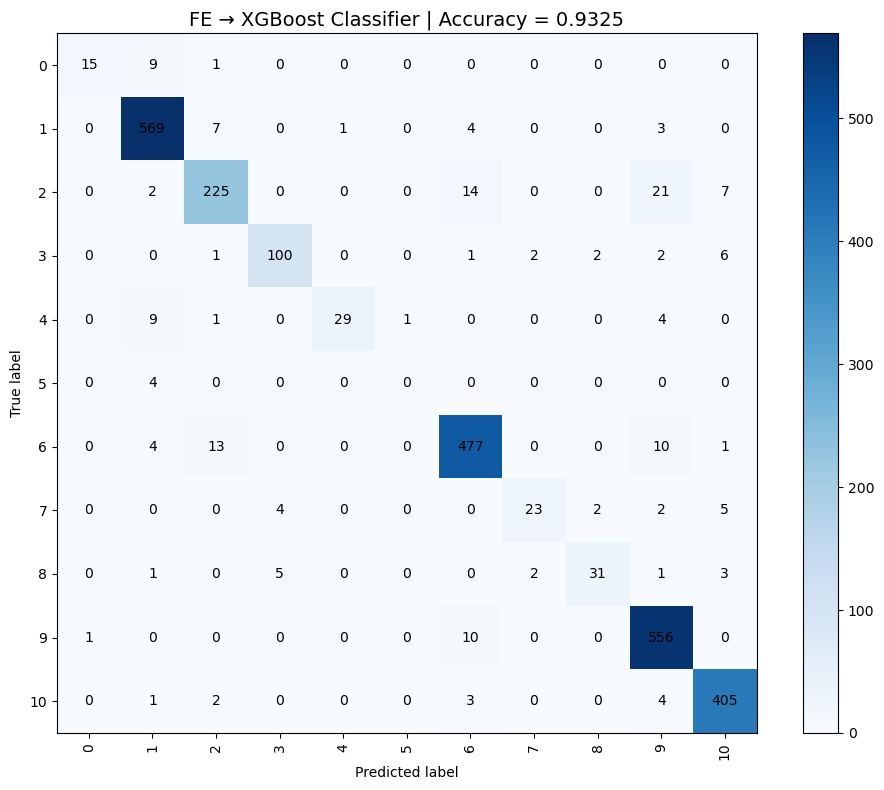

In [12]:
plot_confusion_matrix_clear(
    y_test, y_pred_fe,
    f"FE → XGBoost Classifier | Accuracy = {acc_fe:.4f}"
)


In [13]:
fe_results_df = pd.DataFrame({
    "Model": ["FE → XGBoostClassifier"],
    "Accuracy": [acc_fe],
    "F1 Micro": [f1_micro_fe],
    "ROC AUC Micro": [roc_micro_fe]
})

display(fe_results_df)


,Model,Accuracy,F1 Micro,ROC AUC Micro
0,FE → XGBoostClassifier,0.932464,0.932464,0.996671


In [14]:
print("--- FE → XGBoost SINIF BAZLI PERFORMANS ---")
display(report_table(y_test, y_pred_fe))


--- FE → XGBoost SINIF BAZLI PERFORMANS ---


,precision,recall,f1-score,support
0,0.937500,0.600000,0.731707,25.000000
1,0.949917,0.974315,0.961961,584.000000
2,0.900000,0.836431,0.867052,269.000000
3,0.917431,0.877193,0.896861,114.000000
4,0.966667,0.659091,0.783784,44.000000
5,0.000000,0.000000,0.000000,4.000000
6,0.937132,0.944554,0.940828,505.000000
7,0.851852,0.638889,0.730159,36.000000
8,0.885714,0.720930,0.794872,43.000000
9,0.922056,0.980600,0.950427,567.000000


In [20]:
k = 64   # 🔴 kritik: 128'den küçük olmalı

selector = SelectKBest(score_func=mutual_info_classif, k=k)

X_train_fs = selector.fit_transform(X_train_fe_num, y_train)
X_test_fs  = selector.transform(X_test_fe_num)

print("FS sonrası X_train:", X_train_fs.shape)
print("FS sonrası X_test :", X_test_fs.shape)


FS sonrası X_train: (10422, 64)
FS sonrası X_test : (2606, 64)


In [21]:
xgb_fefs = make_xgb_model(num_class=num_class, random_state=42)

y_pred_fefs, y_proba_fefs, acc_fefs, f1_micro_fefs, roc_micro_fefs = evaluate_multiclass(
    xgb_fefs,
    X_train_fs, y_train,
    X_test_fs,  y_test,
    num_class=num_class
)

print("FE → FS(MI) → XGBoost bitti.")
print("Accuracy:", acc_fefs, "| F1 Micro:", f1_micro_fefs, "| ROC AUC Micro:", roc_micro_fefs)


FE → FS(MI) → XGBoost bitti.
Accuracy: 0.9186492709132771 | F1 Micro: 0.9186492709132771 | ROC AUC Micro: 0.9958518596614814


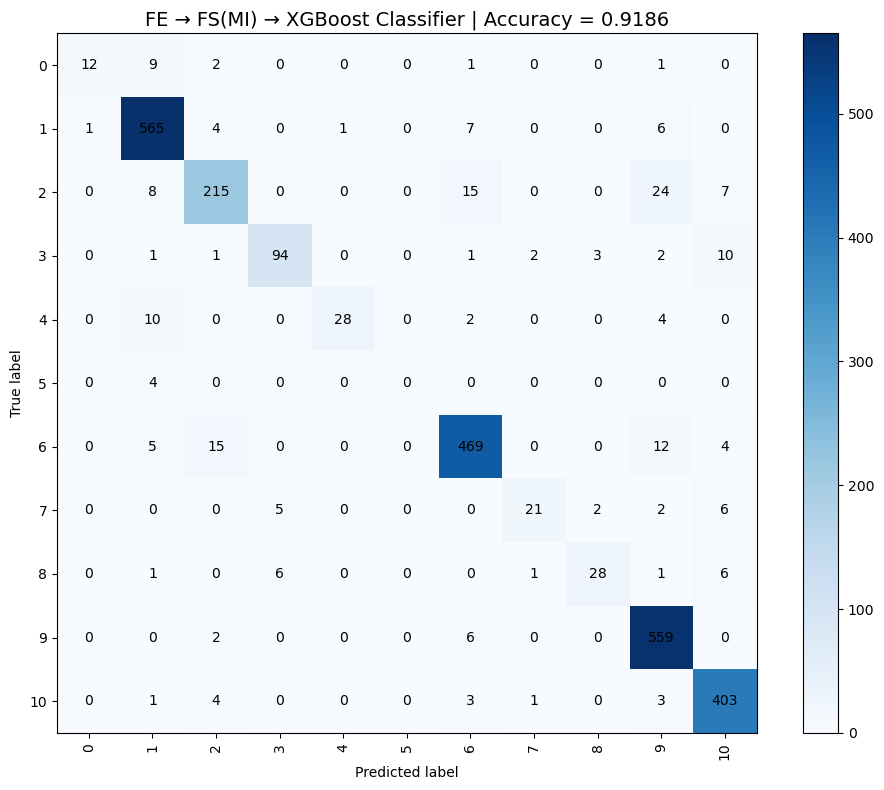

In [22]:
#bu hücrede FE → FS → XGBoost Classifier modelinin test karışıklık matrisini daha büyük ve daha anlaşılır şekilde çiziyorum.
#grafik başlığına doğruluk skorunu ekleyerek görsel bir özet sunuyorum.

plot_confusion_matrix_clear(
    y_test, y_pred_fefs,
    f"FE → FS(MI) → XGBoost Classifier | Accuracy = {acc_fefs:.4f}"
)


In [23]:
comparison_df = pd.DataFrame([
    ["FE → XGBoostClassifier", acc_fe, f1_micro_fe, roc_micro_fe],
    ["FE → FS(MI) → XGBoostClassifier", acc_fefs, f1_micro_fefs, roc_micro_fefs]
], columns=["Model", "Accuracy", "F1 Micro", "ROC AUC Micro"])

display(comparison_df)


,Model,Accuracy,F1 Micro,ROC AUC Micro
0,FE → XGBoostClassifier,0.932464,0.932464,0.996671
1,FE → FS(MI) → XGBoostClassifier,0.918649,0.918649,0.995852


In [24]:
print("--- FE → FS(MI) → XGBoost SINIF BAZLI PERFORMANS ---")
display(report_table(y_test, y_pred_fefs))


--- FE → FS(MI) → XGBoost SINIF BAZLI PERFORMANS ---


,precision,recall,f1-score,support
0,0.923077,0.480000,0.631579,25.000000
1,0.935430,0.967466,0.951178,584.000000
2,0.884774,0.799257,0.839844,269.000000
3,0.895238,0.824561,0.858447,114.000000
4,0.965517,0.636364,0.767123,44.000000
5,0.000000,0.000000,0.000000,4.000000
6,0.930556,0.928713,0.929633,505.000000
7,0.840000,0.583333,0.688525,36.000000
8,0.848485,0.651163,0.736842,43.000000
9,0.910423,0.985891,0.946655,567.000000


In [25]:
comparison_df_round = comparison_df.copy()
comparison_df_round["Accuracy"] = comparison_df_round["Accuracy"].round(4)
comparison_df_round["F1 Micro"] = comparison_df_round["F1 Micro"].round(4)
comparison_df_round["ROC AUC Micro"] = comparison_df_round["ROC AUC Micro"].round(4)

display(comparison_df_round)


,Model,Accuracy,F1 Micro,ROC AUC Micro
0,FE → XGBoostClassifier,0.9325,0.9325,0.9967
1,FE → FS(MI) → XGBoostClassifier,0.9186,0.9186,0.9959


In [26]:
f1_macro_fe = f1_score(y_test, y_pred_fe, average="macro")
f1_weighted_fe = f1_score(y_test, y_pred_fe, average="weighted")

f1_macro_fefs = f1_score(y_test, y_pred_fefs, average="macro")
f1_weighted_fefs = f1_score(y_test, y_pred_fefs, average="weighted")

comparison_plus_df = pd.DataFrame([
    ["FE → XGBoostClassifier", acc_fe, f1_micro_fe, f1_macro_fe, f1_weighted_fe, roc_micro_fe],
    ["FE → FS(MI) → XGBoostClassifier", acc_fefs, f1_micro_fefs, f1_macro_fefs, f1_weighted_fefs, roc_micro_fefs]
], columns=["Model", "Accuracy", "F1 Micro", "F1 Macro", "F1 Weighted", "ROC AUC Micro"])

display(comparison_plus_df.round(4))


,Model,Accuracy,F1 Micro,F1 Macro,F1 Weighted,ROC AUC Micro
0,FE → XGBoostClassifier,0.9325,0.9325,0.7836,0.9301,0.9967
1,FE → FS(MI) → XGBoostClassifier,0.9186,0.9186,0.7543,0.9150,0.9959


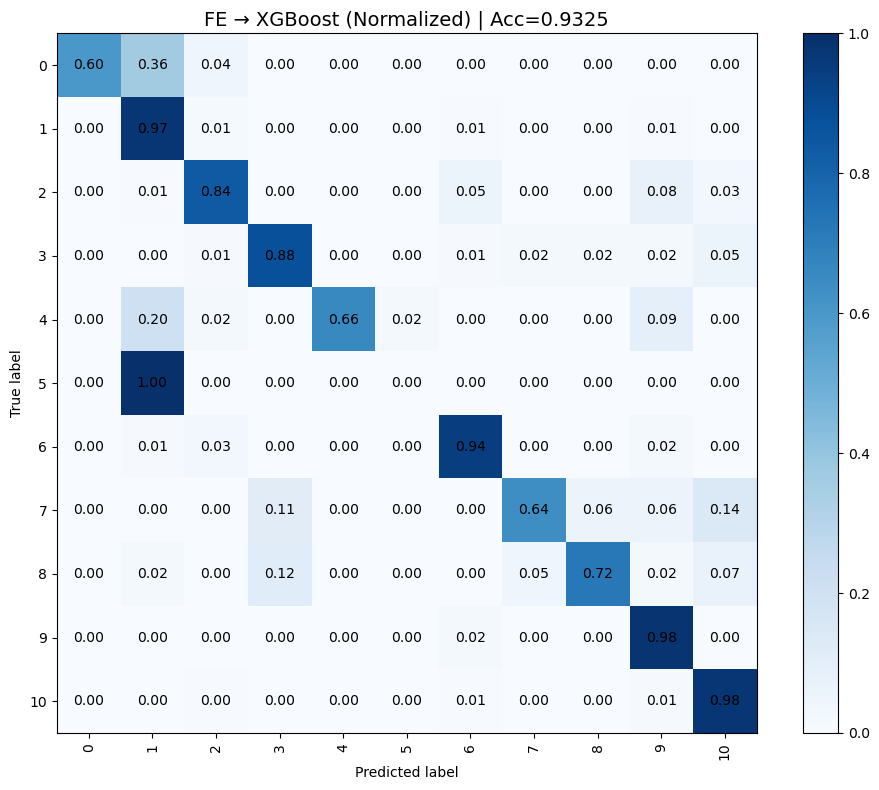

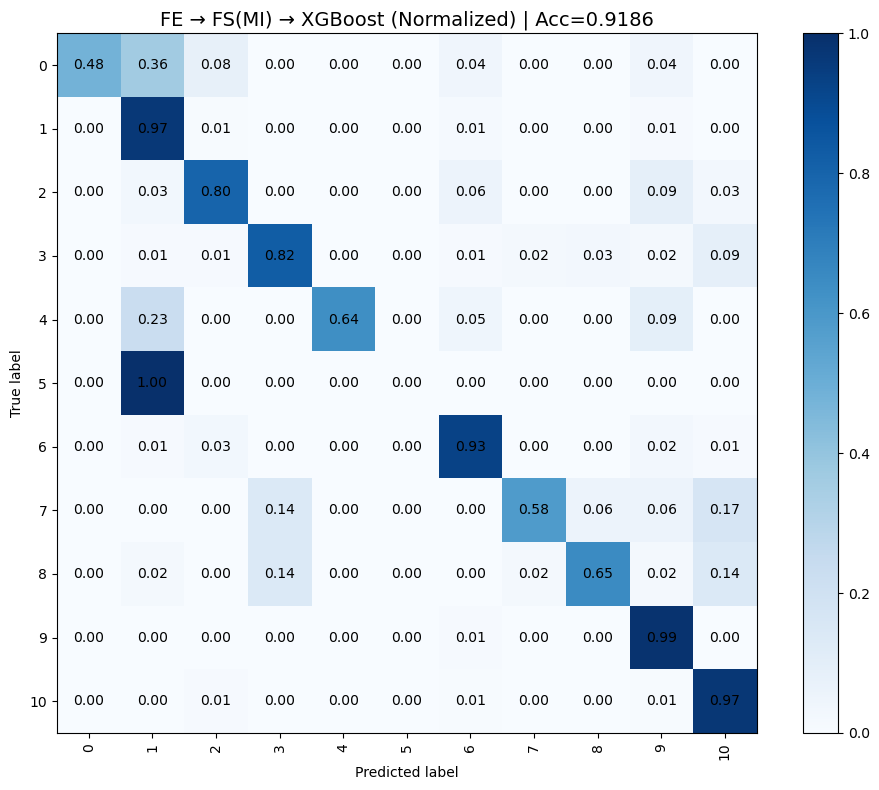

In [27]:
def plot_confusion_matrix_normalized(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred).astype(float)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(10, 8))
    plt.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    plt.title(title, fontsize=14)
    plt.colorbar()

    ticks = np.arange(cm_norm.shape[0])
    plt.xticks(ticks, ticks, rotation=90)
    plt.yticks(ticks, ticks)

    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            plt.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", fontsize=10, color="black")

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix_normalized(y_test, y_pred_fe,   f"FE → XGBoost (Normalized) | Acc={acc_fe:.4f}")
plot_confusion_matrix_normalized(y_test, y_pred_fefs, f"FE → FS(MI) → XGBoost (Normalized) | Acc={acc_fefs:.4f}")


In [28]:
print("===== ÖZET =====")
print(f"FE → XGBoost: Accuracy={acc_fe:.4f}, F1micro={f1_micro_fe:.4f}, ROC-AUCmicro={roc_micro_fe:.4f}")
print(f"FE → FS(MI) → XGBoost: Accuracy={acc_fefs:.4f}, F1micro={f1_micro_fefs:.4f}, ROC-AUCmicro={roc_micro_fefs:.4f}")
print(f"FS ile feature sayısı: {X_train_fe_num.shape[1]} → {X_train_fs.shape[1]}")


===== ÖZET =====
FE → XGBoost: Accuracy=0.9325, F1micro=0.9325, ROC-AUCmicro=0.9967
FE → FS(MI) → XGBoost: Accuracy=0.9186, F1micro=0.9186, ROC-AUCmicro=0.9959
FS ile feature sayısı: 128 → 64


In [29]:
# Encoding sırasına göre sınıf isimleri
target_names = [
    "arc",  # 0
    "bct",  # 1
    "inv",  # 2
    "mam",  # 3
    "phg",  # 4
    "plm",  # 5
    "pln",  # 6
    "pri",  # 7
    "rod",  # 8
    "vrl",  # 9
    "vrt"   # 10
]

print("target_names:", target_names)


target_names: ['arc', 'bct', 'inv', 'mam', 'phg', 'plm', 'pln', 'pri', 'rod', 'vrl', 'vrt']


In [30]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

def print_general_and_class_report_named(y_true, y_pred, model_name="MODEL", target_names=None):
    print(f"{model_name} GENEL PERFORMANS")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, average="weighted", zero_division=0), 4))
    print("Recall   :", round(recall_score(y_true, y_pred, average="weighted", zero_division=0), 4))
    print("F1 Score :", round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4))
    print(f"\n{model_name} SINIF BAZLI PERFORMANS")
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))


In [31]:
print_general_and_class_report_named(
    y_test,
    y_pred_fefs,
    model_name="FE → FS(MI) → XGBoost",
    target_names=target_names
)


FE → FS(MI) → XGBoost GENEL PERFORMANS
Accuracy : 0.9186
Precision: 0.9165
Recall   : 0.9186
F1 Score : 0.915

FE → FS(MI) → XGBoost SINIF BAZLI PERFORMANS
              precision    recall  f1-score   support

         arc       0.92      0.48      0.63        25
         bct       0.94      0.97      0.95       584
         inv       0.88      0.80      0.84       269
         mam       0.90      0.82      0.86       114
         phg       0.97      0.64      0.77        44
         plm       0.00      0.00      0.00         4
         pln       0.93      0.93      0.93       505
         pri       0.84      0.58      0.69        36
         rod       0.85      0.65      0.74        43
         vrl       0.91      0.99      0.95       567
         vrt       0.92      0.97      0.95       415

    accuracy                           0.92      2606
   macro avg       0.82      0.71      0.75      2606
weighted avg       0.92      0.92      0.92      2606



In [32]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


In [33]:
def plot_multiclass_roc(y_true, y_proba, class_names, title):
    """
    y_true      : gerçek etiketler (0,1,2,...)
    y_proba     : predict_proba çıktısı (N x num_class)
    class_names : ["arc","bct",...]
    """

    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

    plt.figure(figsize=(8, 6))

    # Her sınıf için ROC
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

    # Diagonal
    plt.plot([0, 1], [0, 1], "k--", lw=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(fontsize=8, loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


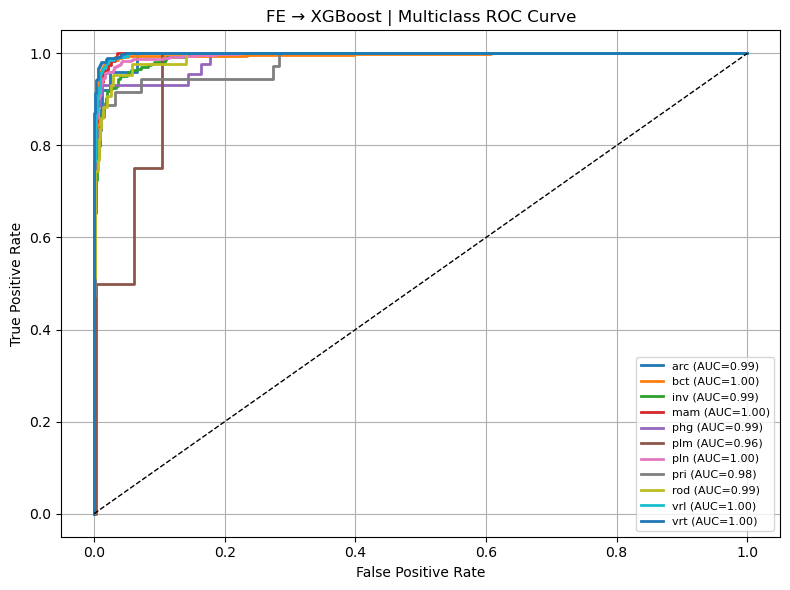

In [34]:
plot_multiclass_roc(
    y_test,
    y_proba_fe,
    class_names=target_names,
    title="FE → XGBoost | Multiclass ROC Curve"
)


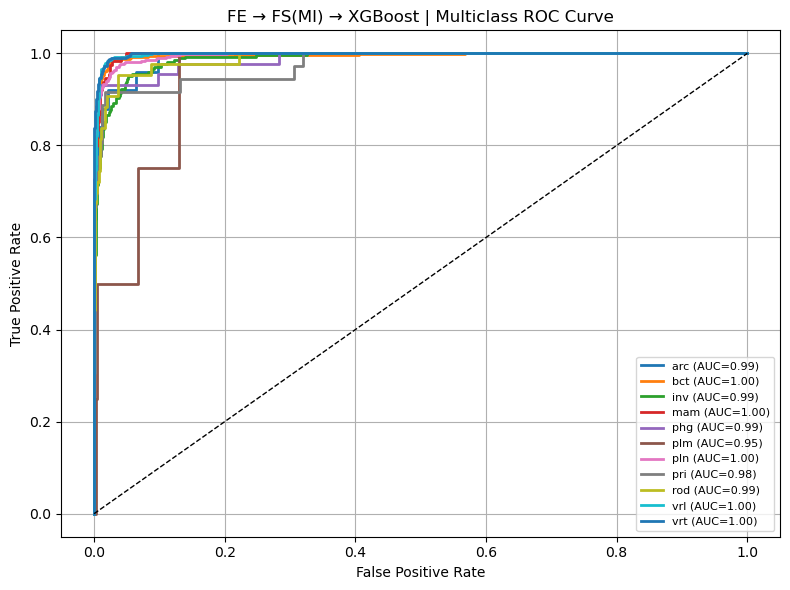

In [35]:
plot_multiclass_roc(
    y_test,
    y_proba_fefs,
    class_names=target_names,
    title="FE → FS(MI) → XGBoost | Multiclass ROC Curve"
)


In [36]:
from sklearn.metrics import roc_auc_score

print("FE → XGBoost ROC AUC (micro):",
      roc_auc_score(y_test, y_proba_fe, multi_class="ovr", average="micro"))

print("FE → FS → XGBoost ROC AUC (micro):",
      roc_auc_score(y_test, y_proba_fefs, multi_class="ovr", average="micro"))


FE → XGBoost ROC AUC (micro): 0.9966711656022555
FE → FS → XGBoost ROC AUC (micro): 0.9958518596614814
